# Vector Arithmetic in Word Embedding Space
Exploring semantic relationships and vector math using GloVe 50-dimensional word embeddings.

In [1]:
import os
import gensim.downloader as api
from gensim.test.utils import datapath
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
from sklearn.decomposition import PCA

# Configure Plotly renderer for Jupyter environments
pio.renderers.default = "notebook_connected"

## 1. Load Pre-trained Word Vectors
We load the `glove-wiki-gigaword-50` dataset via Gensim. This model represents words as 50-dimensional vectors trained on Wikipedia and Gigaword 5 text corpora (~66 MB).

In [2]:
print("Loading GloVe 50-dimensional model...")
model = api.load("glove-wiki-gigaword-50")
print("Model loaded successfully!")

Loading GloVe 50-dimensional model...
Model loaded successfully!


## 2. The Classic Word Vector Analogy
Word embeddings map semantic meaning into spatial directions. By subtracting the "masculine" component from `king` and adding the "feminine" component from `woman`, we can test if the resulting target vector points directly toward `queen`.

$$\vec{v}_{\text{target}} = \vec{v}_{\text{king}} - \vec{v}_{\text{man}} + \vec{v}_{\text{woman}}$$

In [3]:
# Compute E(king) - E(man) + E(woman)
results = model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)

print("Target formula: E(king) - E(man) + E(woman)\n")
print(f"{'Rank':<5} | {'Word':<12} | {'Similarity Score':<16}")
print("-" * 38)
for rank, (word, similarity) in enumerate(results, start=1):
    print(f"{rank:<5} | {word:<12} | {similarity:.4f}")

Target formula: E(king) - E(man) + E(woman)

Rank  | Word         | Similarity Score
--------------------------------------
1     | queen        | 0.8524
2     | throne       | 0.7664
3     | prince       | 0.7592
4     | daughter     | 0.7474
5     | elizabeth    | 0.7460


> **Implementation Note:** You might wonder why "king" or "woman" don't appear as the top similarity hits. Gensim's `most_similar()` method automatically filters out the input query words from its returned list, saving us from having to manually exclude them.

In [4]:
# 1. Define cosine similarity and normalization from scratch, no gensim involved
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def normalize(v: np.ndarray) -> np.ndarray:
    return v / np.linalg.norm(v)

# 2. Naive approach: combine raw vectors first, then compare
target_raw = model['king'] - model['man'] + model['woman']
naive_score = cosine_similarity(target_raw, model['queen'])

# 3. Gensim's actual approach:
# normalize each word vector to unit length before combining them, then compare
target_normed = normalize(model['king']) - normalize(model['man']) + normalize(model['woman'])
normed_score = cosine_similarity(target_normed, model['queen'])

# 4. Compare both manual results against gensim's own reported score
gensim_score = model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)[0][1]

print(f"Naive method (combine raw vectors, then normalize):    {naive_score:.4f}")
print(f"Gensim's method (normalize each vector, then combine): {normed_score:.4f}")
print(f"Gensim's own most_similar score for 'queen':           {gensim_score:.4f}")

Naive method (combine raw vectors, then normalize):    0.8610
Gensim's method (normalize each vector, then combine): 0.8524
Gensim's own most_similar score for 'queen':           0.8524


> **Note on the discrepancy:** `most_similar()` does not normalize the combined target 
> vector. It normalizes each input word vector to unit length individually, then adds 
> and subtracts them. This means a word's magnitude, which correlates with corpus 
> frequency, never gets a vote in the arithmetic, only its direction does. Combining 
> raw vectors first lets longer, more frequent-word vectors dominate the sum, which is 
> why the naive method gives a different score than gensim's actual method.

## 3. Generalizing Analogies: $A$ is to $B$ as $C$ is to $?$
The relationship $A : B :: C : ?$ can be re-formulated as a vector equation:

$$\vec{v}_{\text{target}} = \vec{v}_B - \vec{v}_A + \vec{v}_C$$

We can encapsulate this logic in a function to test whether word embeddings encode broader linguistic properties like geographical relationships, verb tenses, and comparative adjectives.

In [5]:
def solve_analogy(a: str, b: str, c: str, topn: int = 3) -> None:
    """
    Solves the analogy relationship: 'a' is to 'b' as 'c' is to '?'
    Formula: E(b) - E(a) + E(c)
    """
    results = model.most_similar(positive=[b, c], negative=[a], topn=topn)
    
    print(f"Analogy: '{a}' is to '{b}' as '{c}' is to...?")
    for rank, (word, score) in enumerate(results, start=1):
        print(f"  {rank}. {word:<12} (Cosine similarity: {score:.4f})")
    print()

# Test 1: Geographical Capital Cities (France : Paris :: Germany : ?)
solve_analogy("france", "paris", "germany")

# Test 2: Verb Tenses (swim : swimming :: walk : ?)
solve_analogy("swim", "swimming", "walk")

# Test 3: Comparative Adjectives (small : smaller :: big : ?)
solve_analogy("small", "smaller", "big")

Analogy: 'france' is to 'paris' as 'germany' is to...?
  1. berlin       (Cosine similarity: 0.9204)
  2. frankfurt    (Cosine similarity: 0.8202)
  3. vienna       (Cosine similarity: 0.8182)

Analogy: 'swim' is to 'swimming' as 'walk' is to...?
  1. walking      (Cosine similarity: 0.8126)
  2. room         (Cosine similarity: 0.7582)
  3. standing     (Cosine similarity: 0.7532)

Analogy: 'small' is to 'smaller' as 'big' is to...?
  1. bigger       (Cosine similarity: 0.8704)
  2. competitors  (Cosine similarity: 0.7595)
  3. lose         (Cosine similarity: 0.7433)



> **Technical Insights on Vector Analogies**
> 
> **1. The Math (Cosine vs. Euclidean):** Gensim's `most_similar` function calculates **Cosine Similarity** rather than Euclidean distance. 
> 
> $$\cos(\theta) = \frac{\vec{A} \cdot \vec{B}}{\|\vec{A}\|\|\vec{B}\|}$$
> 
> This measures the *angle* between two vectors regardless of their magnitude. This is crucial because frequent words often have longer vectors. By focusing strictly on the directional angle, we isolate the semantic meaning and ignore the raw frequency of the word in the training corpus.
>
> **2. Dimensionality Limits:** While the `swim`:`swimming` :: `walk`:? analogy successfully returned `walking` as its top hit, notice that `room` is immediately behind it. Extremely compressed 50D spaces tend to blur relationships, forcing fine-grained syntactic changes (like verb tenses) to share space with broad, topical co-occurrences (like walking into a room). Higher-dimensional spaces (e.g., 300D) provide enough mathematical "room" to isolate syntactic changes cleanly and push purely topical associates further down the list.

## 4. Geographic Realities and Corpus Biases
Word embeddings capture text frequency and cultural context, not just strict facts. Using `france`:`paris` skews the trajectory toward prominent global hubs (predicting Sydney). Swapping the anchor to `india`:`delhi` pulls `canberra` up to second place (from absent in the top 3 before), though `sydney` remains the top hit either way. This shows the corpus favors population/cultural prominence over administrative status, and the anchor pair only partially corrects for it.

In [6]:
solve_analogy("france", "paris", "australia")

Analogy: 'france' is to 'paris' as 'australia' is to...?
  1. sydney       (Cosine similarity: 0.8964)
  2. london       (Cosine similarity: 0.8507)
  3. melbourne    (Cosine similarity: 0.8494)



In [7]:
solve_analogy("india", "delhi", "australia")

Analogy: 'india' is to 'delhi' as 'australia' is to...?
  1. sydney       (Cosine similarity: 0.8707)
  2. canberra     (Cosine similarity: 0.8660)
  3. melbourne    (Cosine similarity: 0.8339)



## 5. Probing Social Biases
Word embeddings inherit patterns from their training corpora, frequently encoding societal stereotypes. We can use our analogy function to test how the vector space associates gender with specific professions.

In [8]:
solve_analogy("man", "doctor", "woman")

Analogy: 'man' is to 'doctor' as 'woman' is to...?
  1. nurse        (Cosine similarity: 0.8405)
  2. child        (Cosine similarity: 0.7663)
  3. pregnant     (Cosine similarity: 0.7570)



In [9]:
solve_analogy("man", "manager", "woman")

Analogy: 'man' is to 'manager' as 'woman' is to...?
  1. assistant    (Cosine similarity: 0.7486)
  2. owner        (Cosine similarity: 0.7044)
  3. employee     (Cosine similarity: 0.6852)



## 6. Visualizing High-Dimensional Clusters (PCA)
While vector arithmetic operates across all 50 dimensions, human perception is limited to 3D. 

We use **Principal Component Analysis (PCA)** to project the 50D GloVe vectors down to 3 principal axes. This allows us to observe how semantic concepts (royalty/gender, capitals/countries, and objects/vehicles) naturally group together in geometric space.

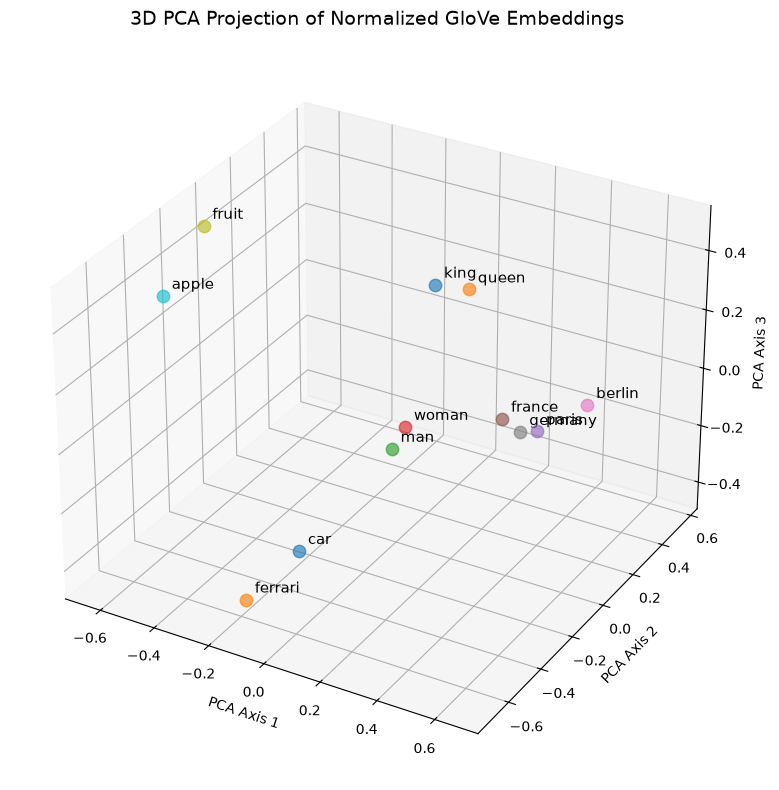

In [10]:
# 1. Select words across distinct semantic categories
words = [
    "king", "queen", "man", "woman", 
    "paris", "france", "berlin", "germany",
    "fruit", "apple", "car", "ferrari"
]

# 2. Extract 50D vectors and reduce to 3D via PCA
vectors = np.array([model[w] for w in words])

# Normalize to length 1 so 3D Euclidean distances accurately reflect Cosine Similarities
vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

pca = PCA(n_components=3)
vectors_3d = pca.fit_transform(vectors)

# 3. Render static 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, word in enumerate(words):
    x, y, z = vectors_3d[i]
    ax.scatter(x, y, z, s=80, alpha=0.8)
    ax.text(x + 0.02, y + 0.02, z + 0.02, word, fontsize=11)

ax.set_xlabel("PCA Axis 1")
ax.set_ylabel("PCA Axis 2")
ax.set_zlabel("PCA Axis 3")
ax.set_title("3D PCA Projection of Normalized GloVe Embeddings", fontsize=14, pad=15)

plt.tight_layout()

# Ensure the outputs directory exists
os.makedirs("outputs", exist_ok=True)

# Save the static plot as a high-resolution PNG
plt.savefig("outputs/glove_pca_3d.png", dpi=300, bbox_inches='tight')

plt.show()

## 7. Interactive Spatial Analysis: Royalty & Gender Cluster
Static plots are useful, but rotating and zooming through vector space provides a much deeper intuition for spatial alignment. 

Below, we isolate a closely related set of terms (`king`, `queen`, `prince`, `princess`, `monarch`, `throne`, `man`, `woman`) and plot them interactively. Rotating the visualization reveals that the gender offsets (e.g., the distance from `king` $\rightarrow$ `queen` and `prince` $\rightarrow$ `princess`) form near-parallel vectors in 3D space.

In [11]:
# 1. Define a focused semantic cluster
words = ["king", "queen", "man", "woman", "prince", "princess", "monarch", "throne"]
vectors = np.array([model[w] for w in words])

# Normalize to length 1 so 3D Euclidean distances accurately reflect Cosine Similarities
vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

# 2. Reduce dimensions from 50D -> 3D
pca = PCA(n_components=3)
vectors_3d = pca.fit_transform(vectors)

# 3. Build DataFrame for Plotly
df = pd.DataFrame(vectors_3d, columns=['PCA 1', 'PCA 2', 'PCA 3'])
df['Word'] = words

# 4. Render interactive 3D scatter plot
fig = px.scatter_3d(
    df, 
    x='PCA 1', 
    y='PCA 2', 
    z='PCA 3', 
    text='Word',
    color='Word',
    title="Interactive 3D Projection: Royalty & Gender Vector Space"
)

fig.update_traces(
    textposition='top center', 
    marker=dict(size=8, opacity=0.8)
)

fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title="PCA 1",
        yaxis_title="PCA 2",
        zaxis_title="PCA 3"
    )
)

fig.show()

# Export interactive standalone HTML file to the outputs folder
fig.write_html("outputs/royalty_gender_pca_3d.html", include_plotlyjs="cdn")

## 8. Quantitative Benchmark: Standard Analogy Test Set
So far every analogy in this notebook was hand-picked. To get an honest measure of accuracy, we run the standard analogy test set from the original word2vec paper (Mikolov et al., 2013), roughly 19,000 analogy questions across 14 categories. It ships with gensim, so no separate download is needed.

In [12]:
# 1. Run the benchmark (takes about 90 seconds on the 50-dimensional model)
accuracy, sections = model.evaluate_word_analogies(datapath('questions-words.txt'))

# 2. Print overall accuracy
print(f"Overall accuracy: {accuracy:.2%}\n")

# 3. Print a per-category breakdown
print(f"{'Category':<30} | {'Correct':>8} | {'Total':>8} | {'Accuracy':>9}")
print("-" * 65)
for s in sections[:-1]:
    correct, incorrect = len(s['correct']), len(s['incorrect'])
    total = correct + incorrect
    acc = correct / total if total else float('nan')
    print(f"{s['section']:<30} | {correct:>8} | {total:>8} | {acc:>9.2%}")

Overall accuracy: 46.37%

Category                       |  Correct |    Total |  Accuracy
-----------------------------------------------------------------
capital-common-countries       |      401 |      506 |    79.25%
capital-world                  |     3099 |     4524 |    68.50%
currency                       |       73 |      808 |     9.03%
city-in-state                  |      378 |     2467 |    15.32%
family                         |      349 |      506 |    68.97%
gram1-adjective-to-adverb      |      151 |      992 |    15.22%
gram2-opposite                 |       77 |      812 |     9.48%
gram3-comparative              |      690 |     1332 |    51.80%
gram4-superlative              |      321 |     1122 |    28.61%
gram5-present-participle       |      439 |     1056 |    41.57%
gram6-nationality-adjective    |     1376 |     1599 |    86.05%
gram7-past-tense               |      585 |     1560 |    37.50%
gram8-plural                   |      798 |     1332 |    59.91

> This model scores 46.37% overall accuracy, but that single number hides wide 
> variance by category: `capital-common-countries` reaches 79%, while `currency` 
> drops to about 9%. Relationships with dense, consistent training signal compress 
> cleanly into linear directions in this 50-dimensional space. Sparser or more 
> context-dependent relationships do not.

## Conclusion

This exploration demonstrates the power and the real limits of static word embeddings. By mapping words into a dense, 50-dimensional space based purely on co-occurrence statistics, GloVe captures a genuine amount of semantic, geographic, and syntactic structure. On the standard word2vec analogy benchmark, this 50-dimensional model scores 46.37% accuracy overall, ranging from 79% on well-represented relationships like common-country capitals down to under 10% on sparser categories like currency. The classic king minus man plus woman equals queen result is a real phenomenon, but it is not the whole story.

### Key Takeaways

* **Semantic Geometry:** Meaning is encoded as direction, not magnitude. This was confirmed directly by hand-computing cosine similarity above, which also revealed that gensim normalizes each word vector before combining them, not after. Getting this arithmetic right by hand once is the difference between trusting a library call and actually understanding what it does.
* **Accuracy Is Category-Dependent, Not Uniform:** A single aggregate score hides significant variance. Relationships with dense, consistent training signal, like capital cities, compress cleanly into linear directions. Sparser or more context-dependent relationships, like currency, do not.
* **Corpus Biases:** Embeddings are not objective ground truths. These models inherit, quantify, and reproduce the societal biases present in their training data.
* **The Context Limitation:** Static embeddings share a critical flaw. The word "bank" has the exact same vector whether it refers to a financial institution or a river edge.

This final limitation is exactly what drove the evolution of modern NLP. Today's Transformer-based architectures solve this by calculating contextual embeddings on the fly, allowing a word's mathematical representation to dynamically shift based on its surrounding sentence. Understanding static models like GloVe, including where they succeed, where they fail, and why, provides the crucial mathematical foundation for mastering those modern systems.